In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [3]:
DATA_PATH = "../data/razorguard_dataset.csv"

df = pd.read_csv(DATA_PATH)

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.shape)
print(df["split"].value_counts())

(10000, 20)
split
train         4929
test          3777
validation    1294
Name: count, dtype: int64


In [4]:
TARGET = "returned"

FEATURES = [
    "return_rate_90d",
    "category_return_rate",
    "is_cod",
    "order_value",
    "discount_pct",
    "delivery_distance_km",
    "previous_returns",
    "customer_age_days",
    "previous_orders",
    "product_rating",
    "orders_last_30d",
    "region_code",
    "browser_family",
    "device_age_days",
    "session_hour"
]

X = df[FEATURES]
y = df[TARGET]

print("Features:", len(FEATURES))
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: 15
X shape: (10000, 15)
y shape: (10000,)


In [5]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4929, 15)
Validation: (1294, 15)
Test: (3777, 15)


In [6]:
majority_model = DummyClassifier(
    strategy="most_frequent"
)

majority_model.fit(X_train, y_train)

majority_pred = majority_model.predict(X_test)

In [7]:
print("Accuracy:", accuracy_score(y_test, majority_pred))
print("Precision:", precision_score(y_test, majority_pred, zero_division=0))
print("Recall:", recall_score(y_test, majority_pred, zero_division=0))
print("F1:", f1_score(y_test, majority_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, majority_pred))

Accuracy: 0.8144029653163887
Precision: 0.0
Recall: 0.0
F1: 0.0

Confusion Matrix:
[[3076    0]
 [ 701    0]]


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    "return_rate_90d",
    "category_return_rate",
    "is_cod",
    "order_value",
    "discount_pct",
    "delivery_distance_km",
    "previous_returns",
    "customer_age_days",
    "previous_orders",
    "product_rating",
    "orders_last_30d",
    "device_age_days",
    "session_hour"
]

categorical_features = [
    "region_code",
    "browser_family"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [9]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['return_rate_90d','category_return_rate','is_cod',...,'browser_family', 'device_age_days','session_hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [10]:
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

In [11]:
print("=== Logistic Regression Baseline ===")

print("Accuracy :", accuracy_score(y_test, logistic_pred))
print("Precision:", precision_score(y_test, logistic_pred, zero_division=0))
print("Recall   :", recall_score(y_test, logistic_pred, zero_division=0))
print("F1       :", f1_score(y_test, logistic_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, logistic_prob))
print("PR-AUC   :", average_precision_score(y_test, logistic_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

=== Logistic Regression Baseline ===
Accuracy : 0.8210219751125232
Precision: 0.5850340136054422
Recall   : 0.12268188302425106
F1       : 0.2028301886792453
ROC-AUC  : 0.6934098417827773
PR-AUC   : 0.3791757995844306

Confusion Matrix:
[[3015   61]
 [ 615   86]]


In [12]:
val_pred = logistic_model.predict(X_val)
val_prob = logistic_model.predict_proba(X_val)[:, 1]

print("=== Validation Performance ===")

print("Accuracy :", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred, zero_division=0))
print("Recall   :", recall_score(y_val, val_pred, zero_division=0))
print("F1       :", f1_score(y_val, val_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_val, val_prob))
print("PR-AUC   :", average_precision_score(y_val, val_prob))

=== Validation Performance ===
Accuracy : 0.8307573415765069
Precision: 0.5072463768115942
Recall   : 0.1590909090909091
F1       : 0.2422145328719723
ROC-AUC  : 0.7076604029117997
PR-AUC   : 0.37039314218563524


In [13]:
baseline_results = pd.DataFrame([
    {
        "model": "Majority Classifier",
        "accuracy": accuracy_score(y_test, majority_pred),
        "precision": precision_score(y_test, majority_pred, zero_division=0),
        "recall": recall_score(y_test, majority_pred, zero_division=0),
        "f1": f1_score(y_test, majority_pred, zero_division=0),
        "roc_auc": np.nan,
        "pr_auc": np.nan
    },
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, logistic_pred),
        "precision": precision_score(y_test, logistic_pred, zero_division=0),
        "recall": recall_score(y_test, logistic_pred, zero_division=0),
        "f1": f1_score(y_test, logistic_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, logistic_prob),
        "pr_auc": average_precision_score(y_test, logistic_prob)
    }
])

baseline_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Majority Classifier,0.814403,0.000000,0.000000,0.00000,NaN,NaN
1,Logistic Regression,0.821022,0.585034,0.122682,0.20283,0.69341,0.379176


In [14]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from catboost import CatBoostClassifier

In [16]:
cat_features = [
    "region_code",
    "browser_family"
]

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

In [17]:
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val_cb, y_val),
    use_best_model=True
)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [18]:
cb_val_prob = catboost_model.predict_proba(X_val_cb)[:, 1]

cb_val_pred = (cb_val_prob >= 0.5).astype(int)

In [19]:
print("=== CatBoost Validation ===")

print("Accuracy :", accuracy_score(y_val, cb_val_pred))
print("Precision:", precision_score(y_val, cb_val_pred, zero_division=0))
print("Recall   :", recall_score(y_val, cb_val_pred, zero_division=0))
print("F1       :", f1_score(y_val, cb_val_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_val, cb_val_prob))
print("PR-AUC   :", average_precision_score(y_val, cb_val_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, cb_val_pred))

=== CatBoost Validation ===
Accuracy : 0.8338485316846986
Precision: 0.5454545454545454
Recall   : 0.13636363636363635
F1       : 0.21818181818181817
ROC-AUC  : 0.7081344167936346
PR-AUC   : 0.3776977131237356

Confusion Matrix:
[[1049   25]
 [ 190   30]]


In [20]:
comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc": roc_auc_score(y_val, val_prob),
        "pr_auc": average_precision_score(y_val, val_prob),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0)
    },
    {
        "model": "CatBoost",
        "roc_auc": roc_auc_score(y_val, cb_val_prob),
        "pr_auc": average_precision_score(y_val, cb_val_prob),
        "f1": f1_score(y_val, cb_val_pred, zero_division=0),
        "precision": precision_score(y_val, cb_val_pred, zero_division=0),
        "recall": recall_score(y_val, cb_val_pred, zero_division=0)
    }
])

comparison.sort_values("pr_auc", ascending=False)

,model,roc_auc,pr_auc,f1,precision,recall
1,CatBoost,0.708134,0.377698,0.218182,0.545455,0.136364
0,Logistic Regression,0.707660,0.370393,0.242215,0.507246,0.159091


In [21]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

In [22]:
lr_prob_true, lr_prob_pred = calibration_curve(
    y_val,
    val_prob,
    n_bins=10,
    strategy="quantile"
)

In [23]:
cb_prob_true, cb_prob_pred = calibration_curve(
    y_val,
    cb_val_prob,
    n_bins=10,
    strategy="quantile"
)

In [24]:
import matplotlib.pyplot as plt


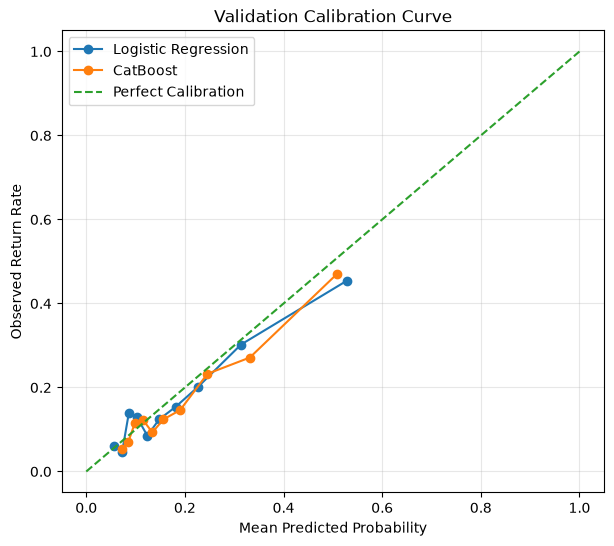

In [25]:
plt.figure(figsize=(7, 6))

plt.plot(
    lr_prob_pred,
    lr_prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    cb_prob_pred,
    cb_prob_true,
    marker="o",
    label="CatBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Return Rate")
plt.title("Validation Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [26]:
lr_brier = brier_score_loss(y_val, val_prob)
cb_brier = brier_score_loss(y_val, cb_val_prob)

print("Logistic Regression Brier Score:", lr_brier)
print("CatBoost Brier Score:", cb_brier)

Logistic Regression Brier Score: 0.12710407788707787
CatBoost Brier Score: 0.12720932221283232


In [27]:
calibration_df = pd.DataFrame({
    "predicted_probability": cb_val_prob,
    "actual_return": y_val.values
})

calibration_df["risk_bin"] = pd.qcut(
    calibration_df["predicted_probability"],
    q=10,
    duplicates="drop"
)

calibration_summary = (
    calibration_df
    .groupby("risk_bin", observed=True)
    .agg(
        predicted_probability=("predicted_probability", "mean"),
        actual_return_rate=("actual_return", "mean"),
        orders=("actual_return", "size")
    )
)

calibration_summary

,predicted_probability,actual_return_rate,orders
risk_bin,,,
"(0.050499999999999996, 0.0782]",0.071735,0.053846,130
"(0.0782, 0.0921]",0.085064,0.069767,129
"(0.0921, 0.106]",0.098687,0.116279,129
"(0.106, 0.123]",0.114705,0.123077,130
"(0.123, 0.145]",0.134025,0.093023,129
"(0.145, 0.168]",0.156280,0.124031,129
"(0.168, 0.214]",0.190303,0.146154,130
"(0.214, 0.282]",0.245605,0.232558,129
"(0.282, 0.39]",0.331605,0.271318,129


In [28]:
# Illustrative merchant economics.
# These are assumptions, not observed Razorpay costs.

RETURN_LOSS_RATE = 0.30       # 30% of order value lost on an undetected return
FALSE_POSITIVE_COST = 75      # operational/customer-friction cost

In [29]:
def evaluate_threshold(
    y_true,
    probabilities,
    order_values,
    threshold,
    return_loss_rate=0.30,
    false_positive_cost=75
):
    predictions = (probabilities >= threshold).astype(int)

    tp = ((predictions == 1) & (y_true == 1)).sum()
    fp = ((predictions == 1) & (y_true == 0)).sum()
    tn = ((predictions == 0) & (y_true == 0)).sum()
    fn = ((predictions == 0) & (y_true == 1)).sum()

    fp_cost = fp * false_positive_cost

    fn_mask = (predictions == 0) & (y_true == 1)
    fn_cost = (
        order_values[fn_mask].sum()
        * return_loss_rate
    )

    total_cost = fp_cost + fn_cost

    return {
        "threshold": threshold,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "false_positive_cost": fp_cost,
        "false_negative_cost": fn_cost,
        "total_cost": total_cost
    }

In [30]:
thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in thresholds:
    result = evaluate_threshold(
        y_true=y_val,
        probabilities=cb_val_prob,
        order_values=X_val["order_value"].to_numpy(),
        threshold=threshold,
        return_loss_rate=RETURN_LOSS_RATE,
        false_positive_cost=FALSE_POSITIVE_COST
    )

    threshold_results.append(result)

threshold_results = pd.DataFrame(threshold_results)

threshold_results.head()

,threshold,tp,fp,tn,fn,precision,recall,f1,false_positive_cost,false_negative_cost,total_cost
0,0.05,220,1074,0,0,0.170015,1.000000,0.290621,80550,0.000,80550.000
1,0.06,220,1071,3,0,0.170411,1.000000,0.291198,80325,0.000,80325.000
2,0.07,217,1041,33,3,0.172496,0.986364,0.293640,78075,617.799,78692.799
3,0.08,212,931,143,8,0.185477,0.963636,0.311079,69825,2362.905,72187.905
4,0.09,206,848,226,14,0.195446,0.936364,0.323391,63600,4707.033,68307.033


In [31]:
best_threshold_row = threshold_results.loc[
    threshold_results["total_cost"].idxmin()
]

best_threshold_row

threshold                  0.140000
tp                       165.000000
fp                       513.000000
tn                       561.000000
fn                        55.000000
precision                  0.243363
recall                     0.750000
f1                         0.367483
false_positive_cost    38475.000000
false_negative_cost    27223.851000
total_cost             65698.851000
Name: 9, dtype: float64

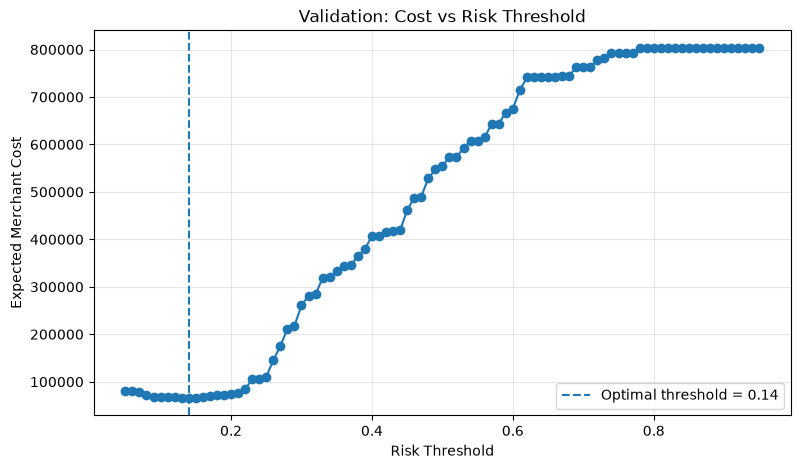

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["total_cost"],
    marker="o"
)

plt.axvline(
    best_threshold_row["threshold"],
    linestyle="--",
    label=f"Optimal threshold = {best_threshold_row['threshold']:.2f}"
)

plt.xlabel("Risk Threshold")
plt.ylabel("Expected Merchant Cost")
plt.title("Validation: Cost vs Risk Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

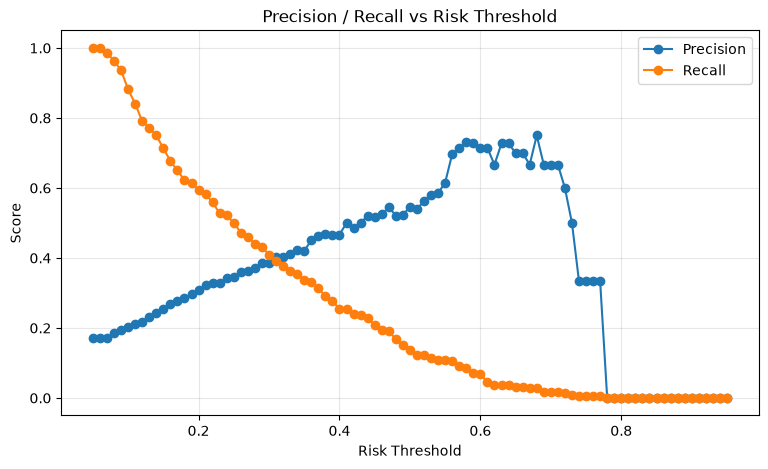

In [33]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Risk Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall vs Risk Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [34]:
sensitivity_results = []

for fp_cost in [25, 50, 75, 100, 150]:
    for loss_rate in [0.20, 0.30, 0.40, 0.50]:

        results = []

        for threshold in thresholds:
            result = evaluate_threshold(
                y_true=y_val,
                probabilities=cb_val_prob,
                order_values=X_val["order_value"].to_numpy(),
                threshold=threshold,
                return_loss_rate=loss_rate,
                false_positive_cost=fp_cost
            )

            results.append(result)

        results_df = pd.DataFrame(results)

        best = results_df.loc[
            results_df["total_cost"].idxmin()
        ]

        sensitivity_results.append({
            "false_positive_cost": fp_cost,
            "return_loss_rate": loss_rate,
            "optimal_threshold": best["threshold"],
            "minimum_cost": best["total_cost"],
            "precision": best["precision"],
            "recall": best["recall"]
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df

,false_positive_cost,return_loss_rate,optimal_threshold,minimum_cost,precision,recall
0,25,0.2,0.09,24338.022,0.195446,0.936364
1,25,0.3,0.08,25637.905,0.185477,0.963636
2,25,0.4,0.08,26425.540,0.185477,0.963636
3,25,0.5,0.06,26775.000,0.170411,1.000000
4,50,0.2,0.14,43799.234,0.243363,0.750000
5,50,0.3,0.09,47107.033,0.195446,0.936364
6,50,0.4,0.09,48676.044,0.195446,0.936364
7,50,0.5,0.09,50245.055,0.195446,0.936364
8,75,0.2,0.16,55120.036,0.267986,0.677273
9,75,0.3,0.14,65698.851,0.243363,0.750000


In [35]:
from sklearn.calibration import CalibratedClassifierCV

In [36]:
import catboost
import sklearn

print(catboost.__version__)
print(sklearn.__version__)


1.2.10
1.9.0


In [37]:
print("df columns:")
print(df.columns.tolist())

print("\ntrain_df columns:")
print(train_df.columns.tolist())

print("\nX_train columns:")
print(X_train.columns.tolist())

df columns:
['order_id', 'customer_id', 'timestamp', 'split', 'return_rate_90d', 'category_return_rate', 'is_cod', 'order_value', 'discount_pct', 'delivery_distance_km', 'previous_returns', 'customer_age_days', 'previous_orders', 'product_rating', 'orders_last_30d', 'region_code', 'browser_family', 'device_age_days', 'session_hour', 'returned']

train_df columns:
['order_id', 'customer_id', 'timestamp', 'split', 'return_rate_90d', 'category_return_rate', 'is_cod', 'order_value', 'discount_pct', 'delivery_distance_km', 'previous_returns', 'customer_age_days', 'previous_orders', 'product_rating', 'orders_last_30d', 'region_code', 'browser_family', 'device_age_days', 'session_hour', 'returned']

X_train columns:
['return_rate_90d', 'category_return_rate', 'is_cod', 'order_value', 'discount_pct', 'delivery_distance_km', 'previous_returns', 'customer_age_days', 'previous_orders', 'product_rating', 'orders_last_30d', 'region_code', 'browser_family', 'device_age_days', 'session_hour']


In [38]:
print("\nIndex samples:")
print("df:", df.index[:5].tolist())
print("train_df:", train_df.index[:5].tolist())
print("X_train:", X_train.index[:5].tolist())


Index samples:
df: [0, 1, 2, 3, 4]
train_df: [0, 1, 2, 3, 4]
X_train: [0, 1, 2, 3, 4]


In [39]:
# Create a temporal split inside the existing training period
# Timestamp is used ONLY for ordering, never as a model feature.

train_dates = pd.to_datetime(train_df["timestamp"])

calibration_cutoff = train_dates.quantile(0.80)

X_model_train = X_train.loc[
    train_dates < calibration_cutoff
].copy()

y_model_train = y_train.loc[X_model_train.index]

X_calibration = X_train.loc[
    train_dates >= calibration_cutoff
].copy()

y_calibration = y_train.loc[X_calibration.index]

print("Model training:", X_model_train.shape)
print("Calibration:", X_calibration.shape)

print("\nModel training period:")
print(train_df.loc[X_model_train.index, "timestamp"].min(),
      "→",
      train_df.loc[X_model_train.index, "timestamp"].max())

print("\nCalibration period:")
print(train_df.loc[X_calibration.index, "timestamp"].min(),
      "→",
      train_df.loc[X_calibration.index, "timestamp"].max())

Model training: (3943, 15)
Calibration: (986, 15)

Model training period:
2026-01-01 00:17:42 → 2026-05-08 09:43:28

Calibration period:
2026-05-08 09:53:05 → 2026-05-31 23:50:17


In [40]:
X_model_train_cb = X_model_train.copy()
X_calibration_cb = X_calibration.copy()

for col in cat_features:
    X_model_train_cb[col] = X_model_train_cb[col].astype(str)
    X_calibration_cb[col] = X_calibration_cb[col].astype(str)

In [41]:
calibration_base_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

calibration_base_model.fit(
    X_model_train_cb,
    y_model_train,
    cat_features=cat_features
)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [42]:
calibration_prob = calibration_base_model.predict_proba(
    X_calibration_cb
)[:, 1]

In [43]:
from sklearn.linear_model import LogisticRegression

calibrator = LogisticRegression()

calibrator.fit(
    calibration_prob.reshape(-1, 1),
    y_calibration
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [44]:
calibrated_val_prob = calibrator.predict_proba(
    cb_val_prob.reshape(-1, 1)
)[:, 1]

In [45]:
calibration_val_prob_raw = calibration_base_model.predict_proba(
    X_val_cb
)[:, 1]

calibrated_val_prob = calibrator.predict_proba(
    calibration_val_prob_raw.reshape(-1, 1)
)[:, 1]

In [46]:
calibrated_brier = brier_score_loss(
    y_val,
    calibrated_val_prob
)

print("Calibrated CatBoost Brier Score:", calibrated_brier)

print(
    "Calibrated ROC-AUC:",
    roc_auc_score(y_val, calibrated_val_prob)
)

print(
    "Calibrated PR-AUC:",
    average_precision_score(y_val, calibrated_val_prob)
)

Calibrated CatBoost Brier Score: 0.13229173178737325
Calibrated ROC-AUC: 0.6620027086507535
Calibrated PR-AUC: 0.32639822036768656


In [47]:
print("Variables currently available:")
print("df:", "df" in globals())
print("train_df:", "train_df" in globals())
print("X_train:", "X_train" in globals())
print("X_val:", "X_val" in globals())
print("y_train:", "y_train" in globals())
print("y_val:", "y_val" in globals())
print("cat_features:", "cat_features" in globals())

Variables currently available:
df: True
train_df: True
X_train: True
X_val: True
y_train: True
y_val: True
cat_features: True


In [48]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/razorguard_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nSplits:")
print(df["split"].value_counts())

Shape: (10000, 20)

Columns:
['order_id', 'customer_id', 'timestamp', 'split', 'return_rate_90d', 'category_return_rate', 'is_cod', 'order_value', 'discount_pct', 'delivery_distance_km', 'previous_returns', 'customer_age_days', 'previous_orders', 'product_rating', 'orders_last_30d', 'region_code', 'browser_family', 'device_age_days', 'session_hour', 'returned']

Splits:
split
train         4929
test          3777
validation    1294
Name: count, dtype: int64


In [49]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

TARGET = "returned"

DROP_COLS = [
    "order_id",
    "customer_id",
    "timestamp",
    "split",
    TARGET
]

FEATURE_COLS = [
    col for col in df.columns
    if col not in DROP_COLS
]

X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET].copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4929, 15)
Validation: (1294, 15)
Test: (3777, 15)


In [50]:
cat_features = [
    "region_code",
    "browser_family"
]

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

In [51]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features
)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [52]:
cb_val_prob = catboost_model.predict_proba(
    X_val_cb
)[:, 1]

print("First 5 probabilities:")
print(cb_val_prob[:5])

print("\nValidation rows:", len(cb_val_prob))
print("Validation labels:", len(y_val))

First 5 probabilities:
[0.08456117 0.32173173 0.14283677 0.37416932 0.0569738 ]

Validation rows: 1294
Validation labels: 1294


In [53]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, cb_val_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, cb_val_prob)
)

ROC-AUC: 0.6733197900795667
PR-AUC: 0.33405353392660825


In [54]:
print("Train shape:", X_train_cb.shape)
print("Validation shape:", X_val_cb.shape)

print("\nCategorical columns:")
print(cat_features)

print("\nTarget rates:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())

print("\nFeature columns:")
print(X_train_cb.columns.tolist())

Train shape: (4929, 15)
Validation shape: (1294, 15)

Categorical columns:
['region_code', 'browser_family']

Target rates:
Train: 0.17934672347332117
Validation: 0.17001545595054096

Feature columns:
['return_rate_90d', 'category_return_rate', 'is_cod', 'order_value', 'discount_pct', 'delivery_distance_km', 'previous_returns', 'customer_age_days', 'previous_orders', 'product_rating', 'orders_last_30d', 'region_code', 'browser_family', 'device_age_days', 'session_hour']


In [55]:
print(catboost_model.get_params())

{'iterations': 500, 'learning_rate': 0.05, 'depth': 6, 'loss_function': 'Logloss', 'random_seed': 42, 'verbose': False, 'eval_metric': 'AUC'}


In [56]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Fresh model — same parameters as the original experiment
cb_model_repro = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

cb_model_repro.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features
)

cb_val_prob_repro = cb_model_repro.predict_proba(
    X_val_cb
)[:, 1]

cb_val_pred_repro = (cb_val_prob_repro >= 0.5).astype(int)

print("=== Reproduced CatBoost Validation ===")
print("Accuracy :", accuracy_score(y_val, cb_val_pred_repro))
print("Precision:", precision_score(y_val, cb_val_pred_repro, zero_division=0))
print("Recall   :", recall_score(y_val, cb_val_pred_repro, zero_division=0))
print("F1       :", f1_score(y_val, cb_val_pred_repro, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_val, cb_val_prob_repro))
print("PR-AUC   :", average_precision_score(y_val, cb_val_prob_repro))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, cb_val_pred_repro))

=== Reproduced CatBoost Validation ===
Accuracy : 0.8268933539412674
Precision: 0.4722222222222222
Recall   : 0.15454545454545454
F1       : 0.2328767123287671
ROC-AUC  : 0.6733197900795667
PR-AUC   : 0.33405353392660825

Confusion Matrix:
[[1036   38]
 [ 186   34]]


In [57]:
print("Unique categorical values:")

for col in cat_features:
    print(f"\n{col}")
    print("Train:", X_train_cb[col].nunique(), X_train_cb[col].unique())
    print("Val  :", X_val_cb[col].nunique(), X_val_cb[col].unique())

Unique categorical values:

region_code
Train: 5 <StringArray>
['north', 'central', 'east', 'west', 'south']
Length: 5, dtype: str
Val  : 5 <StringArray>
['east', 'west', 'south', 'central', 'north']
Length: 5, dtype: str

browser_family
Train: 5 <StringArray>
['edge', 'firefox', 'chrome', 'in_app_webview', 'safari']
Length: 5, dtype: str
Val  : 5 <StringArray>
['chrome', 'firefox', 'safari', 'in_app_webview', 'edge']
Length: 5, dtype: str


In [58]:
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train_cb.columns,
    "importance": cb_model_repro.get_feature_importance()
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
3,order_value,14.017536
4,discount_pct,10.622710
1,category_return_rate,10.473702
5,delivery_distance_km,10.344684
13,device_age_days,9.619279
7,customer_age_days,9.044610
14,session_hour,7.190411
9,product_rating,6.542347
0,return_rate_90d,5.560479
2,is_cod,4.426567


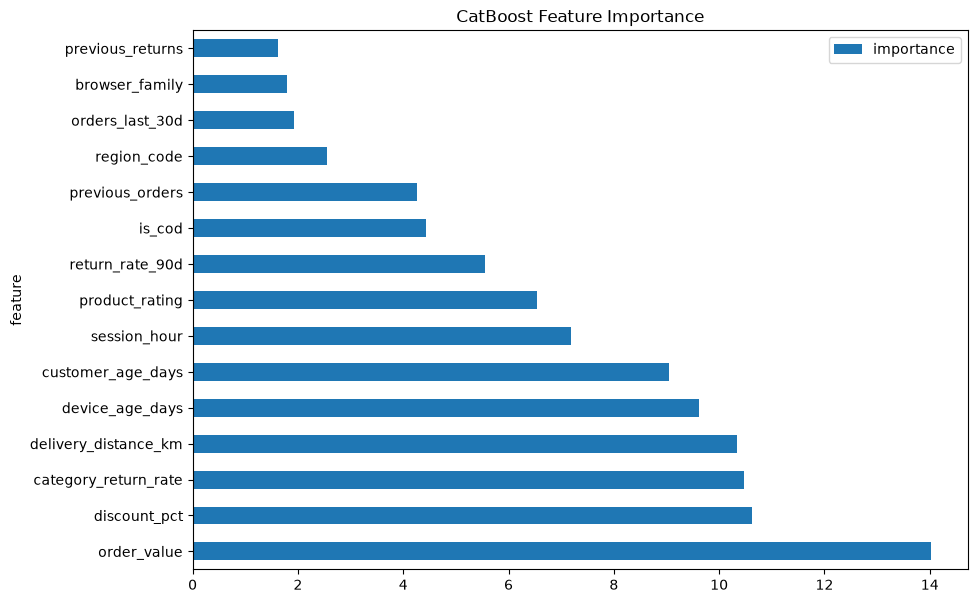

In [59]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 7),
    title="CatBoost Feature Importance"
);

In [60]:
print("Top 10 features:")
print(feature_importance.head(10).to_string(index=False))

Top 10 features:
             feature  importance
         order_value   14.017536
        discount_pct   10.622710
category_return_rate   10.473702
delivery_distance_km   10.344684
     device_age_days    9.619279
   customer_age_days    9.044610
        session_hour    7.190411
      product_rating    6.542347
     return_rate_90d    5.560479
              is_cod    4.426567


In [61]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

models = {
    "CatBoost_baseline": CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    ),

    "CatBoost_deeper": CatBoostClassifier(
        iterations=700,
        depth=7,
        learning_rate=0.04,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    ),

    "CatBoost_regularized": CatBoostClassifier(
        iterations=700,
        depth=5,
        learning_rate=0.04,
        l2_leaf_reg=5,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )
}

results = []

for name, model in models.items():

    model.fit(
        X_train_cb,
        y_train,
        cat_features=cat_features
    )

    prob = model.predict_proba(X_val_cb)[:, 1]

    results.append({
        "model": name,
        "ROC-AUC": roc_auc_score(y_val, prob),
        "PR-AUC": average_precision_score(y_val, prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "PR-AUC",
    ascending=False
)

,model,ROC-AUC,PR-AUC
2,CatBoost_regularized,0.669697,0.335133
0,CatBoost_baseline,0.673320,0.334054
1,CatBoost_deeper,0.671187,0.321782


In [62]:
final_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

final_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features
)

final_val_prob = final_model.predict_proba(
    X_val_cb
)[:, 1]

print("Final frozen model")
print("ROC-AUC:",
      roc_auc_score(y_val, final_val_prob))

print("PR-AUC:",
      average_precision_score(y_val, final_val_prob))

Final frozen model
ROC-AUC: 0.6733197900795667
PR-AUC: 0.33405353392660825


In [63]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/razorguard_catboost_baseline.pkl"
)

print("Model saved.")

Model saved.


In [64]:
final_model.save_model(
    "../models/razorguard_catboost_baseline.cbm"
)

print("CatBoost model saved.")

CatBoost model saved.


In [65]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
import shap

print("SHAP version:", shap.__version__)

c:\Users\kisho\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


In [67]:
# Explain a small validation batch first
X_shap = X_val_cb.iloc[:100].copy()

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP calculated successfully.")
print("Shape:", np.array(shap_values).shape)

SHAP calculated successfully.
Shape: (100, 15)


In [68]:
import pandas as pd
import numpy as np

# Convert SHAP values to DataFrame
shap_df = pd.DataFrame(
    np.abs(shap_values),
    columns=X_shap.columns
)

global_shap_importance = (
    shap_df
    .mean()
    .sort_values(ascending=False)
    .to_frame("mean_abs_shap")
)

global_shap_importance

,mean_abs_shap
order_value,0.426492
is_cod,0.345276
return_rate_90d,0.327887
category_return_rate,0.154410
delivery_distance_km,0.131538
device_age_days,0.102779
discount_pct,0.101947
customer_age_days,0.084657
previous_returns,0.081088
session_hour,0.074069


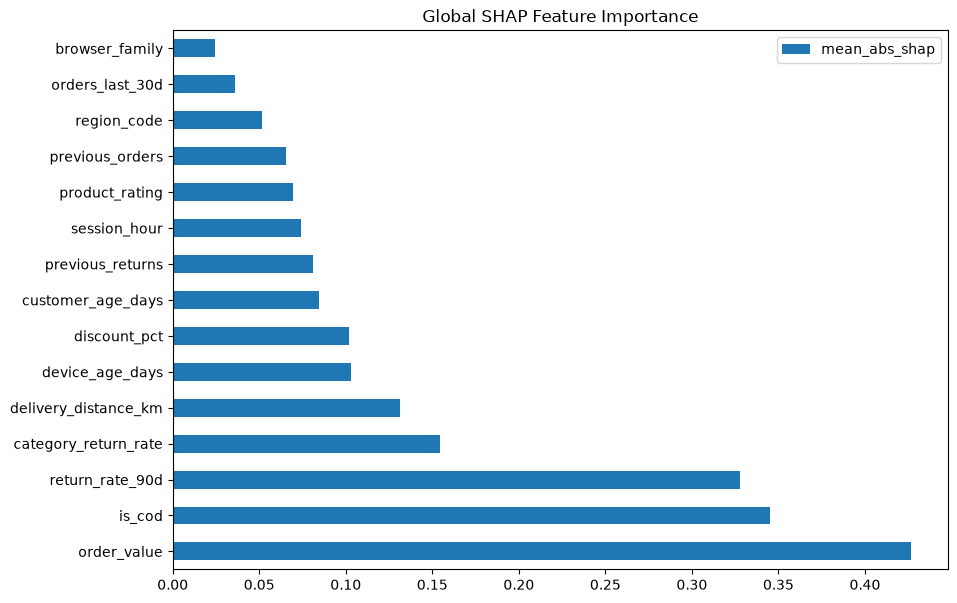

In [69]:
global_shap_importance.plot(
    kind="barh",
    figsize=(10, 7),
    title="Global SHAP Feature Importance"
);

In [70]:
# Pick one validation order
idx = 0

order = X_shap.iloc[idx]
order_shap = shap_values[idx]

explanation_df = pd.DataFrame({
    "feature": X_shap.columns,
    "feature_value": order.values,
    "shap_value": order_shap
})

explanation_df["abs_shap"] = explanation_df["shap_value"].abs()

explanation_df = explanation_df.sort_values(
    "abs_shap",
    ascending=False
)

explanation_df.head(10)

,feature,feature_value,shap_value,abs_shap
10,orders_last_30d,4,-0.547805,0.547805
2,is_cod,True,0.463384,0.463384
3,order_value,1121.56,-0.329431,0.329431
4,discount_pct,0.1599,-0.258129,0.258129
8,previous_orders,12,-0.205186,0.205186
5,delivery_distance_km,297.3,0.133073,0.133073
6,previous_returns,1,0.123946,0.123946
7,customer_age_days,528,0.123469,0.123469
13,device_age_days,969,0.099128,0.099128
0,return_rate_90d,0.166667,-0.073818,0.073818


In [71]:
print("Risk probability:",
      final_val_prob[idx])

print("\nTop risk drivers:")

for _, row in explanation_df.head(5).iterrows():
    direction = "increased" if row["shap_value"] > 0 else "decreased"

    print(
        f"- {row['feature']} = {row['feature_value']} "
        f"→ {direction} risk "
        f"(SHAP={row['shap_value']:.4f})"
    )

Risk probability: 0.08456117345547638

Top risk drivers:
- orders_last_30d = 4 → decreased risk (SHAP=-0.5478)
- is_cod = True → increased risk (SHAP=0.4634)
- order_value = 1121.56 → decreased risk (SHAP=-0.3294)
- discount_pct = 0.1599 → decreased risk (SHAP=-0.2581)
- previous_orders = 12 → decreased risk (SHAP=-0.2052)


In [72]:
feature_cols = X_train.columns.tolist()

In [73]:
print("SHAP values shape:", shap_values.shape)
print("Feature count:", len(feature_cols))
print("Feature names:", feature_cols)

SHAP values shape: (100, 15)
Feature count: 15
Feature names: ['return_rate_90d', 'category_return_rate', 'is_cod', 'order_value', 'discount_pct', 'delivery_distance_km', 'previous_returns', 'customer_age_days', 'previous_orders', 'product_rating', 'orders_last_30d', 'region_code', 'browser_family', 'device_age_days', 'session_hour']


In [74]:
import pandas as pd
import numpy as np

def to_python_value(value):
    if isinstance(value, np.generic):
        return value.item()
    return value

def get_shap_evidence(
    sample_position,
    shap_values,
    X_data,
    predicted_probabilities,
    feature_names,
    top_k=5
):
    """
    Convert raw SHAP output into structured, auditable evidence.

    sample_position:
        Position inside the SHAP sample, e.g. 0 for the first row.

    shap_values:
        SHAP matrix for the selected samples.

    X_data:
        Corresponding feature dataframe.

    predicted_probabilities:
        Model probabilities for the same samples.

    feature_names:
        Model feature names.

    top_k:
        Number of strongest SHAP drivers to retain.
    """

    shap_row = np.asarray(shap_values[sample_position]).flatten()

    probability = float(predicted_probabilities[sample_position])

    evidence = []

    for feature, shap_value in zip(feature_names, shap_row):

        value = X_data.iloc[sample_position][feature]

        if shap_value > 0:
            direction = "increases_risk"
        elif shap_value < 0:
            direction = "decreases_risk"
        else:
            direction = "neutral"

        evidence.append({
            "feature": feature,
            "value": to_python_value(value),
            "shap_value": float(shap_value),
            "absolute_shap": float(abs(shap_value)),
            "direction": direction
        })

    # Strongest drivers first
    evidence = sorted(
        evidence,
        key=lambda x: x["absolute_shap"],
        reverse=True
    )

    return {
        "risk_probability": probability,
        "top_drivers": evidence[:top_k]
    }

In [75]:
def get_risk_level(probability):
    if probability < 0.20:
        return "LOW"
    elif probability < 0.50:
        return "MEDIUM"
    else:
        return "HIGH"

In [76]:
print(X_shap.shape)
print(X_shap.head())

(100, 15)
      return_rate_90d  category_return_rate  is_cod  order_value  \
4929         0.166667              0.163885    True      1121.56   
4930         0.500000              0.090333    True      1811.35   
4931         0.000000              0.202786    True      1035.49   
4932         1.000000              0.197044   False      1043.46   
4933         0.000000              0.163636   False      1362.42   

      discount_pct  delivery_distance_km  previous_returns  customer_age_days  \
4929        0.1599                 297.3                 1                528   
4930        0.1266                 259.1                 1                523   
4931        0.3318                 265.4                 0                407   
4932        0.1817                 361.7                 1                 87   
4933        0.1731                 331.3                 0                 42   

      previous_orders  product_rating  orders_last_30d region_code  \
4929               12   

In [77]:
shap_sample_prob = final_model.predict_proba(
    X_shap
)[:, 1]

print("Probability shape:", shap_sample_prob.shape)
print("First 5 probabilities:", shap_sample_prob[:5])

Probability shape: (100,)
First 5 probabilities: [0.08456117 0.32173173 0.14283677 0.37416932 0.0569738 ]


In [78]:
evidence_0 = get_shap_evidence(
    sample_position=0,
    shap_values=shap_values,
    X_data=X_shap,
    predicted_probabilities=shap_sample_prob,
    feature_names=feature_cols,
    top_k=5
)

evidence_0["risk_level"] = get_risk_level(
    evidence_0["risk_probability"]
)

evidence_0

{'risk_probability': 0.08456117345547638,
 'top_drivers': [{'feature': 'orders_last_30d',
   'value': 4,
   'shap_value': -0.5478054302139812,
   'absolute_shap': 0.5478054302139812,
   'direction': 'decreases_risk'},
  {'feature': 'is_cod',
   'value': True,
   'shap_value': 0.463383546953178,
   'absolute_shap': 0.463383546953178,
   'direction': 'increases_risk'},
  {'feature': 'order_value',
   'value': 1121.56,
   'shap_value': -0.32943092662630136,
   'absolute_shap': 0.32943092662630136,
   'direction': 'decreases_risk'},
  {'feature': 'discount_pct',
   'value': 0.1599,
   'shap_value': -0.25812885616024783,
   'absolute_shap': 0.25812885616024783,
   'direction': 'decreases_risk'},
  {'feature': 'previous_orders',
   'value': 12,
   'shap_value': -0.205185755169526,
   'absolute_shap': 0.205185755169526,
   'direction': 'decreases_risk'}],
 'risk_level': 'LOW'}

In [79]:
def create_deterministic_explanation(evidence):
    probability = evidence["risk_probability"]
    risk_level = evidence["risk_level"]
    drivers = evidence["top_drivers"]

    sentences = []

    for driver in drivers[:3]:

        feature = driver["feature"]
        value = driver["value"]
        direction = driver["direction"]

        if direction == "increases_risk":
            effect = "increased"
        elif direction == "decreases_risk":
            effect = "decreased"
        else:
            effect = "had little effect on"

        sentences.append(
            f"{feature} = {value} {effect} the predicted return risk"
        )

    explanation = (
        f"Predicted return risk is {probability:.1%} "
        f"({risk_level}). "
        + "; ".join(sentences)
        + "."
    )

    return explanation

In [80]:
explanation_0 = create_deterministic_explanation(evidence_0)

print(explanation_0)

Predicted return risk is 8.5% (LOW). orders_last_30d = 4 decreased the predicted return risk; is_cod = True increased the predicted return risk; order_value = 1121.56 decreased the predicted return risk.


In [81]:
structured_evidence = {
    "model": {
        "name": "CatBoost",
        "version": "frozen_v1",
        "roc_auc": 0.6733197900795667,
        "pr_auc": 0.33405353392660825
    },
    "prediction": {
        "probability": evidence_0["risk_probability"],
        "risk_level": evidence_0["risk_level"]
    },
    "evidence": evidence_0["top_drivers"],
    "deterministic_explanation": explanation_0
}

structured_evidence

{'model': {'name': 'CatBoost',
  'version': 'frozen_v1',
  'roc_auc': 0.6733197900795667,
  'pr_auc': 0.33405353392660825},
 'prediction': {'probability': 0.08456117345547638, 'risk_level': 'LOW'},
 'evidence': [{'feature': 'orders_last_30d',
   'value': 4,
   'shap_value': -0.5478054302139812,
   'absolute_shap': 0.5478054302139812,
   'direction': 'decreases_risk'},
  {'feature': 'is_cod',
   'value': True,
   'shap_value': 0.463383546953178,
   'absolute_shap': 0.463383546953178,
   'direction': 'increases_risk'},
  {'feature': 'order_value',
   'value': 1121.56,
   'shap_value': -0.32943092662630136,
   'absolute_shap': 0.32943092662630136,
   'direction': 'decreases_risk'},
  {'feature': 'discount_pct',
   'value': 0.1599,
   'shap_value': -0.25812885616024783,
   'absolute_shap': 0.25812885616024783,
   'direction': 'decreases_risk'},
  {'feature': 'previous_orders',
   'value': 12,
   'shap_value': -0.205185755169526,
   'absolute_shap': 0.205185755169526,
   'direction': 'decre

In [82]:
LLM_SYSTEM_PROMPT = """
You are a risk-explanation assistant for a merchant return-risk system.

Your ONLY job is to explain the evidence produced by the ML model.

STRICT RULES:

1. Use ONLY the evidence provided in the input.
2. Do not invent customer history, order information, or business facts.
3. Do not change or reinterpret the risk probability.
4. Do not change the risk level.
5. Do not invent features that are not present in the evidence.
6. Do not invent feature values.
7. Do not claim causation. Describe features as model evidence or model drivers.
8. Clearly distinguish factors that increase risk from factors that decrease risk.
9. Keep the explanation concise and understandable to a merchant.
10. If the evidence is insufficient to explain something, explicitly say so.

Return ONLY valid JSON with this structure:

{
    "summary": "...",
    "risk_probability": 0.0,
    "risk_level": "LOW",
    "drivers": [
        {
            "feature": "...",
            "direction": "increases_risk",
            "value": "...",
            "explanation": "..."
        }
    ]
}
"""

In [83]:
llm_evidence = {
    "risk_probability": structured_evidence["prediction"]["probability"],
    "risk_level": structured_evidence["prediction"]["risk_level"],
    "top_drivers": structured_evidence["evidence"][:5]
}

llm_evidence

{'risk_probability': 0.08456117345547638,
 'risk_level': 'LOW',
 'top_drivers': [{'feature': 'orders_last_30d',
   'value': 4,
   'shap_value': -0.5478054302139812,
   'absolute_shap': 0.5478054302139812,
   'direction': 'decreases_risk'},
  {'feature': 'is_cod',
   'value': True,
   'shap_value': 0.463383546953178,
   'absolute_shap': 0.463383546953178,
   'direction': 'increases_risk'},
  {'feature': 'order_value',
   'value': 1121.56,
   'shap_value': -0.32943092662630136,
   'absolute_shap': 0.32943092662630136,
   'direction': 'decreases_risk'},
  {'feature': 'discount_pct',
   'value': 0.1599,
   'shap_value': -0.25812885616024783,
   'absolute_shap': 0.25812885616024783,
   'direction': 'decreases_risk'},
  {'feature': 'previous_orders',
   'value': 12,
   'shap_value': -0.205185755169526,
   'absolute_shap': 0.205185755169526,
   'direction': 'decreases_risk'}]}

In [84]:
import json

llm_input = json.dumps(
    llm_evidence,
    indent=2
)

print(llm_input)

{
  "risk_probability": 0.08456117345547638,
  "risk_level": "LOW",
  "top_drivers": [
    {
      "feature": "orders_last_30d",
      "value": 4,
      "shap_value": -0.5478054302139812,
      "absolute_shap": 0.5478054302139812,
      "direction": "decreases_risk"
    },
    {
      "feature": "is_cod",
      "value": true,
      "shap_value": 0.463383546953178,
      "absolute_shap": 0.463383546953178,
      "direction": "increases_risk"
    },
    {
      "feature": "order_value",
      "value": 1121.56,
      "shap_value": -0.32943092662630136,
      "absolute_shap": 0.32943092662630136,
      "direction": "decreases_risk"
    },
    {
      "feature": "discount_pct",
      "value": 0.1599,
      "shap_value": -0.25812885616024783,
      "absolute_shap": 0.25812885616024783,
      "direction": "decreases_risk"
    },
    {
      "feature": "previous_orders",
      "value": 12,
      "shap_value": -0.205185755169526,
      "absolute_shap": 0.205185755169526,
      "direction": "dec

In [85]:
LLM_USER_PROMPT = f"""
Explain the following ML risk evidence to a merchant.

Evidence:

{llm_input}

Remember:
- Use only the supplied evidence.
- Do not invent facts.
- Do not change the probability or risk level.
- Explain the strongest risk-increasing and risk-decreasing drivers.
- Do not claim that a feature causes the return.
- Return only the required JSON structure.
"""

In [86]:
pip install openai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
pip install dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [88]:
pip install groq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [141]:
def generate_llm_explanation(evidence):
    """
    Generate a human-readable explanation from structured SHAP evidence.

    The LLM does NOT receive raw order data.
    It only receives the model's already-computed evidence.
    """

    prompt = f"""
You are an AI risk explanation assistant.

Your job is ONLY to explain an existing ML prediction.
You must NOT recalculate risk, invent evidence, or change the model's decision.

Use ONLY the structured evidence provided below.

Risk probability:
{evidence["risk_probability"]:.4f}

Risk level:
{evidence["risk_level"]}

Top SHAP drivers:
{json.dumps(evidence["top_drivers"], indent=2, default=str)}

STRICT DIRECTION RULES:
- If a driver's direction is "increases_risk", you MUST explicitly say that
  the feature "increases risk".
- If a driver's direction is "decreases_risk", you MUST explicitly say that
  the feature "decreases risk".
- NEVER reverse or reinterpret the direction from the SHAP value.
- The "direction" field is authoritative.
- Do not describe a feature as increasing risk if its direction is
  "decreases_risk", and vice versa.

Requirements:
1. State the predicted return-risk percentage.
2. State the risk level.
3. Mention the top 5 supplied drivers.
4. For EVERY driver, preserve its supplied direction.
5. Use the supplied feature names and values.
6. You may mention SHAP values, but they must not change the stated direction.
7. Do not invent customer behavior, product information, or business context.
8. Do not recommend an action.
9. Do not claim causation. Use "contributes to" or "is associated with".
10. Do not mention unsupported features.
11. Keep the explanation under 120 words.

Return only the explanation.
"""

    response = groq_client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "system",
                "content": (
                    "You explain ML predictions faithfully. "
                    "Never contradict structured evidence."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip()

In [142]:
llm_explanation = generate_llm_explanation(llm_evidence)

print(llm_explanation)

The model predicts an 8.46% return‑risk, classified as LOW. The top drivers are: orders_last_30d = 4, which is associated with decreasing risk (SHAP −0.548); is_cod = true, which is associated with increasing risk (SHAP +0.463); order_value = 1121.56, which is associated with decreasing risk (SHAP −0.329); discount_pct = 0.1599, which is associated with decreasing risk (SHAP −0.258); previous_orders = 12, which is associated with decreasing risk (SHAP −0.205).


In [144]:
print("structured_evidence keys:", structured_evidence.keys())
print("llm_evidence keys:", llm_evidence.keys())

structured_evidence keys: dict_keys(['model', 'prediction', 'evidence', 'deterministic_explanation'])
llm_evidence keys: dict_keys(['risk_probability', 'risk_level', 'top_drivers'])


In [165]:
llm_validation = validate_llm_explanation(
    llm_explanation,
    structured_evidence
)

print(llm_validation)

{'valid': False, 'errors': ["LLM explanation may contradict SHAP direction for 'orders_last_30d'.", "LLM explanation may contradict SHAP direction for 'is_cod'.", "LLM explanation may contradict SHAP direction for 'order_value'.", "LLM explanation may contradict SHAP direction for 'discount_pct'."]}


In [92]:
successful_llm_explanation = llm_explanation

print(successful_llm_explanation)

The model predicts a return‑risk probability of **0.0846** (8.5 %) and classifies the order as **LOW** risk.

**Key drivers of this prediction**

| Feature | Value | Effect on risk |
|---------|-------|----------------|
| `orders_last_30d` | 4 | decreases risk (SHAP = ‑0.548) |
| `is_cod` | true | increases risk (SHAP = +0.463) |
| `order_value` | 1121.56 | decreases risk (SHAP = ‑0.329) |
| `discount_pct` | 0.1599 | decreases risk (SHAP = ‑0.258) |
| `previous


In [93]:
print("LLM explanation generated successfully.")
print("Length:", len(successful_llm_explanation))

LLM explanation generated successfully.
Length: 465


In [94]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\razorguard


In [95]:
from src.validator import validate_prediction

In [96]:
validation_result = validate_prediction(result)

print(validation_result)

{'valid': False, 'errors': ["Missing top-level fields: ['deterministic_explanation', 'evidence', 'model', 'prediction']"]}


In [97]:
print(type(result))
print(result.keys() if isinstance(result, dict) else result)

<class 'dict'>
dict_keys(['threshold', 'tp', 'fp', 'tn', 'fn', 'precision', 'recall', 'f1', 'false_positive_cost', 'false_negative_cost', 'total_cost'])


In [98]:
for name, value in list(globals().items()):
    if isinstance(value, dict):
        keys = set(value.keys())

        if {"model", "prediction", "evidence"}.issubset(keys):
            print("FOUND:", name)
            print("Keys:", value.keys())

FOUND: structured_evidence
Keys: dict_keys(['model', 'prediction', 'evidence', 'deterministic_explanation'])
FOUND: _81
Keys: dict_keys(['model', 'prediction', 'evidence', 'deterministic_explanation'])


In [99]:
validation_result = validate_prediction(structured_evidence)

print(validation_result)

{'valid': True, 'errors': []}


In [100]:
import copy

bad_probability = copy.deepcopy(structured_evidence)

bad_probability["prediction"]["probability"] = 1.5

print(validate_prediction(bad_probability))

{'valid': False, 'errors': ['Prediction probability must be between 0 and 1.']}


In [101]:
bad_risk = copy.deepcopy(structured_evidence)

bad_risk["prediction"]["risk_level"] = "EXTREME"

print(validate_prediction(bad_risk))

{'valid': False, 'errors': ['Invalid risk level: EXTREME']}


In [102]:
bad_direction = copy.deepcopy(structured_evidence)

bad_direction["evidence"][0]["direction"] = "increases_risk"

print(validate_prediction(bad_direction))

{'valid': False, 'errors': ["Evidence item 0: direction 'increases_risk' does not match SHAP sign."]}


In [103]:
bad_absolute_shap = copy.deepcopy(structured_evidence)

bad_absolute_shap["evidence"][0]["absolute_shap"] = 999

print(validate_prediction(bad_absolute_shap))

{'valid': False, 'errors': ['Evidence item 0: absolute_shap does not match abs(shap_value).']}


In [154]:
import importlib
import src.validator as validator

importlib.reload(validator)

<module 'src.validator' from 'd:\\razorguard\\src\\validator.py'>

In [157]:
validate_llm_explanation = validator.validate_llm_explanation

In [159]:
llm_validation = validate_llm_explanation(
    llm_explanation,
    structured_evidence
)

print(llm_validation)

{'valid': False, 'errors': ["LLM explanation may contradict SHAP direction for 'orders_last_30d'.", "LLM explanation may contradict SHAP direction for 'is_cod'.", "LLM explanation may contradict SHAP direction for 'order_value'.", "LLM explanation may contradict SHAP direction for 'discount_pct'."]}


In [107]:
bad_llm_1 = llm_explanation.replace("8.5%", "75.0%")

print(
    validate_llm_explanation(
        bad_llm_1,
        structured_evidence
    )
)

{'valid': False, 'errors': ["LLM explanation does not mention SHAP feature 'previous_orders'."]}


In [108]:
bad_llm_2 = llm_explanation.replace(
    "is_cod = true – increases risk",
    "is_cod = true – decreases risk"
)

print(
    validate_llm_explanation(
        bad_llm_2,
        structured_evidence
    )
)

{'valid': False, 'errors': ["LLM explanation does not mention SHAP feature 'previous_orders'."]}


In [109]:
bad_llm_3 = llm_explanation + (
    "\ncustomer_income = 50000 strongly increases risk."
)

print(
    validate_llm_explanation(
        bad_llm_3,
        structured_evidence
    )
)

{'valid': False, 'errors': ["LLM explanation may contain an unsupported feature: 'customer_income'.", "LLM explanation may contain an unsupported feature: 'income'.", "LLM explanation does not mention SHAP feature 'previous_orders'."]}


In [110]:
bad_llm_4 = ""

print(
    validate_llm_explanation(
        bad_llm_4,
        structured_evidence
    )
)

{'valid': False, 'errors': ['LLM explanation cannot be empty.']}


In [111]:
print(llm_explanation)

The model predicts a return‑risk probability of **0.0846** (8.5 %) and classifies the order as **LOW** risk.

**Key drivers of this prediction**

| Feature | Value | Effect on risk |
|---------|-------|----------------|
| `orders_last_30d` | 4 | decreases risk (SHAP = ‑0.548) |
| `is_cod` | true | increases risk (SHAP = +0.463) |
| `order_value` | 1121.56 | decreases risk (SHAP = ‑0.329) |
| `discount_pct` | 0.1599 | decreases risk (SHAP = ‑0.258) |
| `previous


In [112]:
bad_llm_2 = llm_explanation.replace(
    "increases risk",
    "decreases risk"
)

print(bad_llm_2)

The model predicts a return‑risk probability of **0.0846** (8.5 %) and classifies the order as **LOW** risk.

**Key drivers of this prediction**

| Feature | Value | Effect on risk |
|---------|-------|----------------|
| `orders_last_30d` | 4 | decreases risk (SHAP = ‑0.548) |
| `is_cod` | true | decreases risk (SHAP = +0.463) |
| `order_value` | 1121.56 | decreases risk (SHAP = ‑0.329) |
| `discount_pct` | 0.1599 | decreases risk (SHAP = ‑0.258) |
| `previous


In [113]:
print(
    validate_llm_explanation(
        bad_llm_2,
        structured_evidence
    )
)

{'valid': False, 'errors': ["LLM explanation does not mention SHAP feature 'previous_orders'.", "LLM explanation may contradict SHAP direction for 'is_cod'."]}


In [114]:
print("=== CURRENT PIPELINE OBJECTS ===")

objects_to_check = [
    "frozen_model",
    "final_model",
    "catboost_model",
    "calibration_base_model",
    "calibrator",
    "structured_evidence",
    "llm_evidence",
    "llm_explanation",
    "validate_prediction",
    "validate_llm_explanation",
    "get_shap_evidence",
    "generate_llm_explanation",
]

for name in objects_to_check:
    print(f"{name}: {'AVAILABLE' if name in globals() else 'NOT AVAILABLE'}")

=== CURRENT PIPELINE OBJECTS ===
frozen_model: NOT AVAILABLE
final_model: AVAILABLE
catboost_model: AVAILABLE
calibration_base_model: AVAILABLE
calibrator: AVAILABLE
structured_evidence: AVAILABLE
llm_evidence: AVAILABLE
llm_explanation: AVAILABLE
validate_prediction: AVAILABLE
validate_llm_explanation: AVAILABLE
get_shap_evidence: AVAILABLE
generate_llm_explanation: AVAILABLE


In [115]:
print("=== VALIDATOR IMPORT ===")

try:
    import src.validator as validator
    print("validator module: AVAILABLE")
    
    print(
        "validate_prediction:",
        hasattr(validator, "validate_prediction")
    )
    
    print(
        "validate_llm_explanation:",
        hasattr(validator, "validate_llm_explanation")
    )

except Exception as e:
    print("Validator import error:", repr(e))

=== VALIDATOR IMPORT ===
validator module: AVAILABLE
validate_prediction: True
validate_llm_explanation: True


In [186]:
def run_end_to_end(order_row):
    """
    Complete return-risk prediction pipeline.

    Flow:
    Input
      -> CatBoost prediction
      -> SHAP evidence
      -> Structured evidence
      -> LLM explanation
      -> LLM validation
    """

    input_validation = validate_input_order(order_row)
    if not input_validation["valid"]:
        return {
            "status": "FAILED",
            "errors": input_validation["errors"]
        }


    # ---------------------------------------------------------
    # 1. Prepare input
    # ---------------------------------------------------------

    input_df = order_row.copy()


    # CatBoost categorical columns must be strings
    for col in cat_features:
        if col in input_df.columns:
            input_df[col] = input_df[col].astype(str)

    # ---------------------------------------------------------
    # 2. Model prediction
    # ---------------------------------------------------------

    probability = float(
        final_model.predict_proba(input_df)[:, 1][0]
    )

    # Risk level
    if probability >= 0.50:
        risk_level = "HIGH"
    elif probability >= 0.20:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    # ---------------------------------------------------------
    # 3. Generate SHAP values
    # ---------------------------------------------------------
    import shap

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(input_df)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    # ---------------------------------------------------------
    # 3. Generate structured SHAP evidence
    # ---------------------------------------------------------

    predicted_probabilities = pd.Series(
        [probability],
        index=input_df.index
    )
    
    evidence_result = get_shap_evidence(
        0,
        shap_values,
        input_df,
        predicted_probabilities,
        list(input_df.columns),
        top_k=5
    )

    # ---------------------------------------------------------
    # 4. Build structured evidence
    # ---------------------------------------------------------

    structured_result = {
        "model": {
            "name": "CatBoost",
            "version": "frozen_v1",
            "roc_auc": 0.6733197900795667,
            "pr_auc": 0.33405353392660825
        },

        "prediction": {
            "probability": probability,
            "risk_level": risk_level
        },

        "evidence": evidence_result["top_drivers"],

        "deterministic_explanation": (
            f"Predicted return risk is {probability:.1%} "
            f"({risk_level}). "
            + "; ".join(
                f"{driver['feature']} = {driver['value']} "
                f"{driver['direction'].replace('_', ' ')}"
                for driver in evidence_result["top_drivers"][:3]
            )
            + "."
        )
    }

    # ---------------------------------------------------------
    # 5. Validate structured evidence
    # ---------------------------------------------------------

    structured_validation = validate_prediction(
        structured_result
    )

    if not structured_validation["valid"]:
        return {
            "status": "FAILED",
            "stage": "structured_validation",
            "validation": structured_validation
        }

    # ---------------------------------------------------------
    # 6. Prepare evidence for LLM
    # ---------------------------------------------------------

    llm_evidence = {
        "risk_probability": probability,
        "risk_level": risk_level,
        "top_drivers": structured_result["evidence"][:5]
    }

    # ---------------------------------------------------------
    # 7. Generate LLM explanation
    # ---------------------------------------------------------

    explanation = generate_llm_explanation(
        llm_evidence
    )

    # ---------------------------------------------------------
    # 8. Validate LLM explanation
    # ---------------------------------------------------------

    llm_validation = validate_llm_explanation(
        explanation,
        structured_result
    )

    # ---------------------------------------------------------
    # 9. Final result
    # ---------------------------------------------------------

    return {
        "status": "SUCCESS" if llm_validation["valid"] else "FAILED",

        "prediction": structured_result["prediction"],

        "evidence": structured_result["evidence"],

        "deterministic_explanation":
            structured_result["deterministic_explanation"],

        "llm_explanation": explanation,

        "validation": {
            "structured": structured_validation,
            "llm": llm_validation
        }
    }

In [130]:
# Take one real row from the validation set
test_order = X_val.iloc[[0]].copy()

print("Test order shape:", test_order.shape)
print("\nTest order:")
display(test_order)

Test order shape: (1, 15)

Test order:


,return_rate_90d,category_return_rate,is_cod,order_value,discount_pct,delivery_distance_km,previous_returns,customer_age_days,previous_orders,product_rating,orders_last_30d,region_code,browser_family,device_age_days,session_hour
4929,0.166667,0.163885,True,1121.56,0.1599,297.3,1,528,12,4.22,4,east,chrome,969,2


In [132]:
test_order = X_val.iloc[[0]].copy()

# Reset index so the single test row has index 0
test_order = test_order.reset_index(drop=True)

print(test_order.index)

RangeIndex(start=0, stop=1, step=1)


In [137]:
result = run_end_to_end(test_order)

print(result)

{'status': 'FAILED', 'prediction': {'probability': 0.08456117345547638, 'risk_level': 'LOW'}, 'evidence': [{'feature': 'orders_last_30d', 'value': 4, 'shap_value': -0.5478054302139812, 'absolute_shap': 0.5478054302139812, 'direction': 'decreases_risk'}, {'feature': 'is_cod', 'value': True, 'shap_value': 0.463383546953178, 'absolute_shap': 0.463383546953178, 'direction': 'increases_risk'}, {'feature': 'order_value', 'value': 1121.56, 'shap_value': -0.32943092662630136, 'absolute_shap': 0.32943092662630136, 'direction': 'decreases_risk'}, {'feature': 'discount_pct', 'value': 0.1599, 'shap_value': -0.25812885616024783, 'absolute_shap': 0.25812885616024783, 'direction': 'decreases_risk'}, {'feature': 'previous_orders', 'value': 12, 'shap_value': -0.205185755169526, 'absolute_shap': 0.205185755169526, 'direction': 'decreases_risk'}], 'deterministic_explanation': 'Predicted return risk is 8.5% (LOW). orders_last_30d = 4 decreases risk; is_cod = True increases risk; order_value = 1121.56 decr

In [ ]:
def generate_llm_explanation(evidence):

    prompt = f"""
You are an AI risk explanation assistant for an e-commerce return-risk system.

Your job is ONLY to explain the machine-learning prediction using the
structured SHAP evidence provided below.

STRICT RULES:
1. Use ONLY the information present in the evidence.
2. Do not invent features, values, customer behavior, or reasons.
3. Do not change or contradict SHAP directions.
4. Do not make a feature sound risky if its direction is "decreases_risk".
5. State the predicted risk probability and risk level.
6. Mention the most important drivers.
7. Keep the explanation concise and merchant-friendly.
8. Do not claim that SHAP proves causation.
9. Do not make recommendations or take actions.
10. Return plain text only.

STRUCTURED SHAP EVIDENCE:
{json.dumps(evidence, indent=2, default=str)}
"""

    response = groq_client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "system",
                "content": (
                    "You produce strictly evidence-grounded explanations "
                    "of machine-learning risk predictions."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        max_tokens=250
    )

    return response.choices[0].message.content

In [166]:
import importlib
import src.validator as validator

importlib.reload(validator)

validate_llm_explanation = validator.validate_llm_explanation
validate_prediction = validator.validate_prediction

print("Validator reloaded successfully")

Validator reloaded successfully


In [167]:
llm_validation = validate_llm_explanation(
    llm_explanation,
    structured_evidence
)

print(llm_validation)

{'valid': True, 'errors': []}


In [168]:
result = run_end_to_end(test_order)

print(result)

{'status': 'SUCCESS', 'prediction': {'probability': 0.08456117345547638, 'risk_level': 'LOW'}, 'evidence': [{'feature': 'orders_last_30d', 'value': 4, 'shap_value': -0.5478054302139812, 'absolute_shap': 0.5478054302139812, 'direction': 'decreases_risk'}, {'feature': 'is_cod', 'value': True, 'shap_value': 0.463383546953178, 'absolute_shap': 0.463383546953178, 'direction': 'increases_risk'}, {'feature': 'order_value', 'value': 1121.56, 'shap_value': -0.32943092662630136, 'absolute_shap': 0.32943092662630136, 'direction': 'decreases_risk'}, {'feature': 'discount_pct', 'value': 0.1599, 'shap_value': -0.25812885616024783, 'absolute_shap': 0.25812885616024783, 'direction': 'decreases_risk'}, {'feature': 'previous_orders', 'value': 12, 'shap_value': -0.205185755169526, 'absolute_shap': 0.205185755169526, 'direction': 'decreases_risk'}], 'deterministic_explanation': 'Predicted return risk is 8.5% (LOW). orders_last_30d = 4 decreases risk; is_cod = True increases risk; order_value = 1121.56 dec

In [169]:
result_normal = run_end_to_end(test_order)

print("STATUS:", result_normal["status"])
print("PROBABILITY:", result_normal["prediction"]["probability"])
print("RISK:", result_normal["prediction"]["risk_level"])
print("STRUCTURED VALID:", result_normal["validation"]["structured"]["valid"])
print("LLM VALID:", result_normal["validation"]["llm"]["valid"])

STATUS: SUCCESS
PROBABILITY: 0.08456117345547638
RISK: LOW
STRUCTURED VALID: True
LLM VALID: True


In [170]:
high_risk_order = test_order.copy()

high_risk_order["return_rate_90d"] = 0.90
high_risk_order["category_return_rate"] = 0.80
high_risk_order["is_cod"] = True
high_risk_order["previous_returns"] = 8
high_risk_order["previous_orders"] = 1
high_risk_order["orders_last_30d"] = 0
high_risk_order["product_rating"] = 1.5
high_risk_order["discount_pct"] = 0.50

In [171]:
result_high = run_end_to_end(high_risk_order)

print("STATUS:", result_high["status"])
print("PROBABILITY:", result_high["prediction"]["probability"])
print("RISK:", result_high["prediction"]["risk_level"])
print("STRUCTURED VALID:", result_high["validation"]["structured"]["valid"])
print("LLM VALID:", result_high["validation"]["llm"]["valid"])

STATUS: SUCCESS
PROBABILITY: 0.44648282139003986
RISK: MEDIUM
STRUCTURED VALID: True
LLM VALID: True


In [172]:
missing_feature_order = test_order.copy()

missing_feature_order["order_value"] = None

In [173]:
result_missing = run_end_to_end(missing_feature_order)

print(result_missing)

{'status': 'SUCCESS', 'prediction': {'probability': 0.05926860320620332, 'risk_level': 'LOW'}, 'evidence': [{'feature': 'order_value', 'value': None, 'shap_value': -0.5615973959382637, 'absolute_shap': 0.5615973959382637, 'direction': 'decreases_risk'}, {'feature': 'orders_last_30d', 'value': 4, 'shap_value': -0.5494792158452023, 'absolute_shap': 0.5494792158452023, 'direction': 'decreases_risk'}, {'feature': 'is_cod', 'value': True, 'shap_value': 0.4977007482855928, 'absolute_shap': 0.4977007482855928, 'direction': 'increases_risk'}, {'feature': 'discount_pct', 'value': 0.1599, 'shap_value': -0.2942019202625658, 'absolute_shap': 0.2942019202625658, 'direction': 'decreases_risk'}, {'feature': 'session_hour', 'value': 2, 'shap_value': -0.14907086589526714, 'absolute_shap': 0.14907086589526714, 'direction': 'decreases_risk'}], 'deterministic_explanation': 'Predicted return risk is 5.9% (LOW). order_value = None decreases risk; orders_last_30d = 4 decreases risk; is_cod = True increases r

In [174]:
wrong_type_order = test_order.copy()

wrong_type_order["order_value"] = "not_a_number"

In [175]:
result_wrong_type = run_end_to_end(wrong_type_order)

print(result_wrong_type)

CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=3]="not_a_number": Cannot convert 'not_a_number' to float

In [176]:
invalid_category_order = test_order.copy()

invalid_category_order["browser_family"] = 12345

In [177]:
result_invalid_category = run_end_to_end(
    invalid_category_order
)

print(result_invalid_category)

{'status': 'SUCCESS', 'prediction': {'probability': 0.10295057816728395, 'risk_level': 'LOW'}, 'evidence': [{'feature': 'orders_last_30d', 'value': 4, 'shap_value': -0.4960176885190879, 'absolute_shap': 0.4960176885190879, 'direction': 'decreases_risk'}, {'feature': 'is_cod', 'value': True, 'shap_value': 0.4558896430541529, 'absolute_shap': 0.4558896430541529, 'direction': 'increases_risk'}, {'feature': 'order_value', 'value': 1121.56, 'shap_value': -0.3837869349960279, 'absolute_shap': 0.3837869349960279, 'direction': 'decreases_risk'}, {'feature': 'discount_pct', 'value': 0.1599, 'shap_value': -0.2864163081135658, 'absolute_shap': 0.2864163081135658, 'direction': 'decreases_risk'}, {'feature': 'browser_family', 'value': '12345', 'shap_value': 0.2263520384671026, 'absolute_shap': 0.2263520384671026, 'direction': 'increases_risk'}], 'deterministic_explanation': 'Predicted return risk is 10.3% (LOW). orders_last_30d = 4 decreases risk; is_cod = True increases risk; order_value = 1121.56

In [178]:
missing_column_order = test_order.copy()

missing_column_order = missing_column_order.drop(
    columns=["order_value"]
)

result_missing_column = run_end_to_end(
    missing_column_order
)

print(result_missing_column)

CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=10]="east": Cannot convert 'east' to float

In [179]:
import inspect

print(inspect.getsource(run_end_to_end))

def run_end_to_end(order_row):
    """
    Complete return-risk prediction pipeline.

    Flow:
    Input
      -> CatBoost prediction
      -> SHAP evidence
      -> Structured evidence
      -> LLM explanation
      -> LLM validation
    """

    # ---------------------------------------------------------
    # 1. Prepare input
    # ---------------------------------------------------------

    input_df = order_row.copy()

    # CatBoost categorical columns must be strings
    for col in cat_features:
        if col in input_df.columns:
            input_df[col] = input_df[col].astype(str)

    # ---------------------------------------------------------
    # 2. Model prediction
    # ---------------------------------------------------------

    probability = float(
        final_model.predict_proba(input_df)[:, 1][0]
    )

    # Risk level
    if probability >= 0.50:
        risk_level = "HIGH"
    elif probability >= 0.20:
        risk_level = "MEDIUM"
    else:
        risk_lev

In [180]:
import inspect

source = inspect.getsource(run_end_to_end)

for i, line in enumerate(source.splitlines(), 1):
    print(f"{i:03}: {line}")

001: def run_end_to_end(order_row):
002:     """
003:     Complete return-risk prediction pipeline.
004: 
005:     Flow:
006:     Input
007:       -> CatBoost prediction
008:       -> SHAP evidence
009:       -> Structured evidence
010:       -> LLM explanation
011:       -> LLM validation
012:     """
013: 
014:     # ---------------------------------------------------------
015:     # 1. Prepare input
016:     # ---------------------------------------------------------
017: 
018:     input_df = order_row.copy()
019: 
020:     # CatBoost categorical columns must be strings
021:     for col in cat_features:
022:         if col in input_df.columns:
023:             input_df[col] = input_df[col].astype(str)
024: 
025:     # ---------------------------------------------------------
026:     # 2. Model prediction
027:     # ---------------------------------------------------------
028: 
029:     probability = float(
030:         final_model.predict_proba(input_df)[:, 1][0]
031:     )
032: 

In [191]:
def validate_input_order(order_row):
    """
    Validate input order before sending it to the ML model.
    """

    errors = []

    # Expected features used by the model
    expected_features = [
        "return_rate_90d",
        "category_return_rate",
        "is_cod",
        "order_value",
        "discount_pct",
        "delivery_distance_km",
        "previous_returns",
        "customer_age_days",
        "previous_orders",
        "product_rating",
        "orders_last_30d",
        "region_code",
        "browser_family",
        "device_age_days",
        "session_hour",
    ]

    # ---------------------------------------------------------
    # 1. Check input type
    # ---------------------------------------------------------

    if not isinstance(order_row, pd.DataFrame):
        errors.append("Input must be a pandas DataFrame.")
        return {
            "valid": False,
            "errors": errors
        }

    # ---------------------------------------------------------
    # 2. Check missing columns
    # ---------------------------------------------------------

    missing_columns = [
        col for col in expected_features
        if col not in order_row.columns
    ]

    if missing_columns:
        errors.append(
            f"Missing required features: {missing_columns}"
        )

    # ---------------------------------------------------------
    # 3. Stop here if columns are missing
    # ---------------------------------------------------------

    if errors:
        return {
            "valid": False,
            "errors": errors
        }

    # ---------------------------------------------------------
    # 4. Check numeric features
    # ---------------------------------------------------------

    numeric_features = [
        "return_rate_90d",
        "category_return_rate",
        "order_value",
        "discount_pct",
        "delivery_distance_km",
        "previous_returns",
        "customer_age_days",
        "previous_orders",
        "product_rating",
        "orders_last_30d",
        "device_age_days",
        "session_hour",
    ]

    for col in numeric_features:

        value = order_row[col].iloc[0]

        if value is None or pd.isna(value):
            errors.append(
                f"Feature '{col}' cannot be missing."
            )
            continue

        try:
            float(value)
        except (TypeError, ValueError):
            errors.append(
                f"Feature '{col}' must be numeric."
            )
        

    # ---------------------------------------------------------
    # 5. Check boolean feature
    # ---------------------------------------------------------

    is_cod_value = order_row["is_cod"].iloc[0]

    if not isinstance(is_cod_value, (bool, np.bool_)):
        errors.append(
            "Feature 'is_cod' must be boolean."
        )

    return {
        "valid": len(errors) == 0,
        "errors": errors
    }

In [185]:
print("NORMAL:")
print(validate_input_order(test_order))

print("\nWRONG TYPE:")
print(validate_input_order(wrong_type_order))

print("\nMISSING COLUMN:")
print(validate_input_order(missing_column_order))

NORMAL:
{'valid': True, 'errors': []}

WRONG TYPE:
{'valid': False, 'errors': ["Feature 'order_value' must be numeric."]}

MISSING COLUMN:
{'valid': False, 'errors': ["Missing required features: ['order_value']"]}


In [187]:
result_normal = run_end_to_end(test_order)

print(result_normal["status"])
print(result_normal["validation"])

SUCCESS
{'structured': {'valid': True, 'errors': []}, 'llm': {'valid': True, 'errors': []}}


In [188]:
result_wrong_type = run_end_to_end(wrong_type_order)

print(result_wrong_type)

{'status': 'FAILED', 'errors': ["Feature 'order_value' must be numeric."]}


In [189]:
result_missing_column = run_end_to_end(
    missing_column_order
)

print(result_missing_column)

{'status': 'FAILED', 'errors': ["Missing required features: ['order_value']"]}


In [190]:
missing_value_order = test_order.copy()

missing_value_order["order_value"] = None

print(validate_input_order(missing_value_order))

{'valid': True, 'errors': []}


In [192]:
missing_value_order = test_order.copy()
missing_value_order["order_value"] = None

print(validate_input_order(missing_value_order))

{'valid': False, 'errors': ["Feature 'order_value' cannot be missing."]}


In [193]:
result_missing_value = run_end_to_end(
    missing_value_order
)

print(result_missing_value)

{'status': 'FAILED', 'errors': ["Feature 'order_value' cannot be missing."]}


In [194]:
print("=" * 70)
print("FINAL END-TO-END TEST SUITE")
print("=" * 70)


# =========================================================
# TEST 1 — Normal valid order
# =========================================================

print("\n[TEST 1] Normal valid order")

result_1 = run_end_to_end(test_order)

print("STATUS:", result_1["status"])
print("PROBABILITY:", result_1["prediction"]["probability"])
print("RISK:", result_1["prediction"]["risk_level"])
print("STRUCTURED VALID:", result_1["validation"]["structured"]["valid"])
print("LLM VALID:", result_1["validation"]["llm"]["valid"])


# =========================================================
# TEST 2 — Medium-risk order
# =========================================================

print("\n[TEST 2] Medium-risk order")

result_2 = run_end_to_end(medium_risk_order)

print("STATUS:", result_2["status"])
print("PROBABILITY:", result_2["prediction"]["probability"])
print("RISK:", result_2["prediction"]["risk_level"])
print("STRUCTURED VALID:", result_2["validation"]["structured"]["valid"])
print("LLM VALID:", result_2["validation"]["llm"]["valid"])


# =========================================================
# TEST 3 — Wrong numeric type
# =========================================================

print("\n[TEST 3] Wrong numeric type")

result_3 = run_end_to_end(wrong_type_order)

print("RESULT:", result_3)


# =========================================================
# TEST 4 — Missing column
# =========================================================

print("\n[TEST 4] Missing required column")

result_4 = run_end_to_end(missing_column_order)

print("RESULT:", result_4)


# =========================================================
# TEST 5 — Missing numeric value
# =========================================================

print("\n[TEST 5] Missing numeric value")

result_5 = run_end_to_end(missing_value_order)

print("RESULT:", result_5)


# =========================================================
# TEST 6 — Invalid boolean
# =========================================================

print("\n[TEST 6] Invalid boolean")

invalid_boolean_order = test_order.copy()
invalid_boolean_order["is_cod"] = "yes"

result_6 = run_end_to_end(invalid_boolean_order)

print("RESULT:", result_6)


# =========================================================
# TEST 7 — Multiple invalid fields
# =========================================================

print("\n[TEST 7] Multiple invalid fields")

multiple_invalid_order = test_order.copy()

multiple_invalid_order["order_value"] = "not_a_number"
multiple_invalid_order["is_cod"] = "yes"

result_7 = run_end_to_end(multiple_invalid_order)

print("RESULT:", result_7)


print("\n" + "=" * 70)
print("FINAL TEST SUITE COMPLETE")
print("=" * 70)

FINAL END-TO-END TEST SUITE

[TEST 1] Normal valid order
STATUS: SUCCESS
PROBABILITY: 0.08456117345547638
RISK: LOW
STRUCTURED VALID: True
LLM VALID: True

[TEST 2] Medium-risk order


NameError: name 'medium_risk_order' is not defined

In [195]:
medium_risk_order = test_order.copy()

# Make the order intentionally more risk-prone
medium_risk_order["orders_last_30d"] = 0
medium_risk_order["previous_orders"] = 0
medium_risk_order["is_cod"] = True
medium_risk_order["discount_pct"] = 0.0

print(medium_risk_order)

   return_rate_90d  category_return_rate  is_cod  order_value  discount_pct  \
0         0.166667              0.163885    True      1121.56           0.0   

   delivery_distance_km  previous_returns  customer_age_days  previous_orders  \
0                 297.3                 1                528                0   

   product_rating  orders_last_30d region_code browser_family  \
0            4.22                0        east         chrome   

   device_age_days  session_hour  
0              969             2  


In [196]:
result_2 = run_end_to_end(medium_risk_order)

print("STATUS:", result_2["status"])
print("PROBABILITY:", result_2["prediction"]["probability"])
print("RISK:", result_2["prediction"]["risk_level"])
print("STRUCTURED VALID:", result_2["validation"]["structured"]["valid"])
print("LLM VALID:", result_2["validation"]["llm"]["valid"])

STATUS: SUCCESS
PROBABILITY: 0.0708932834879102
RISK: LOW
STRUCTURED VALID: True
LLM VALID: True


In [197]:
print("\n[TEST 3] Wrong numeric type")
result_3 = run_end_to_end(wrong_type_order)
print(result_3)

print("\n[TEST 4] Missing required column")
result_4 = run_end_to_end(missing_column_order)
print(result_4)

print("\n[TEST 5] Missing numeric value")
result_5 = run_end_to_end(missing_value_order)
print(result_5)

print("\n[TEST 6] Invalid boolean")

invalid_boolean_order = test_order.copy()
invalid_boolean_order["is_cod"] = "yes"

result_6 = run_end_to_end(invalid_boolean_order)
print(result_6)

print("\n[TEST 7] Multiple invalid fields")

multiple_invalid_order = test_order.copy()
multiple_invalid_order["order_value"] = "not_a_number"
multiple_invalid_order["is_cod"] = "yes"

result_7 = run_end_to_end(multiple_invalid_order)
print(result_7)


[TEST 3] Wrong numeric type
{'status': 'FAILED', 'errors': ["Feature 'order_value' must be numeric."]}

[TEST 4] Missing required column
{'status': 'FAILED', 'errors': ["Missing required features: ['order_value']"]}

[TEST 5] Missing numeric value
{'status': 'FAILED', 'errors': ["Feature 'order_value' cannot be missing."]}

[TEST 6] Invalid boolean
{'status': 'FAILED', 'errors': ["Feature 'is_cod' must be boolean."]}

[TEST 7] Multiple invalid fields
{'status': 'FAILED', 'errors': ["Feature 'order_value' must be numeric.", "Feature 'is_cod' must be boolean."]}
